# Imports

In [1]:
import os
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

project_root = os.path.abspath("../..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(f"Project root: {project_root}")

# Import project modules
from src.datagen import mackey_glass, generate_narma_data
from src.datagen import split_and_scale_series
from src.models import draw_circuit, gqnn_shape
from projects.trainability_effective_dim.model.models import gqnn
from projects.trainability_effective_dim.trainers.hyperparameter_trainer import HyperparameterTrainer
from utils.Charts import multi_plot_flat_ts

from pennylane import numpy as np
import torch
import pennylane as qml
from torch.utils.data import TensorDataset
import optuna

from projects.trainability_effective_dim.trainers.basic_trainer import BasicTrainer
from torch import nn


%load_ext autoreload
%autoreload 2

%aimport -torch
%aimport -numpy
%aimport -qiskit
%aimport -pennylane
%aimport -optuna

### Constants
SEED = 2025
TRAIN_FRACTION = 0.7
FIGURES_DIR = Path("results")  # Results will be saved in the data folder
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sim = "lightning.qubit"  # 'default.qubit' #
interface = "torch"  # 'torch' #
diff_method = (
    "adjoint"  # as we use QRC and no training # 'adjoint' # 'parameter-shift' #
)
level = "gradient"
shots = None

dtype = torch.float64
torch.set_default_dtype(dtype)

# Enable CUDA device if available
torch_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"\nThe optimum devices: {sim} and {torch_device}")

Project root: /home/adrian/Coding-projects/qtsa_expressivity
Project root: /home/adrian/Coding-projects

The optimum devices: lightning.qubit and cpu


## Models

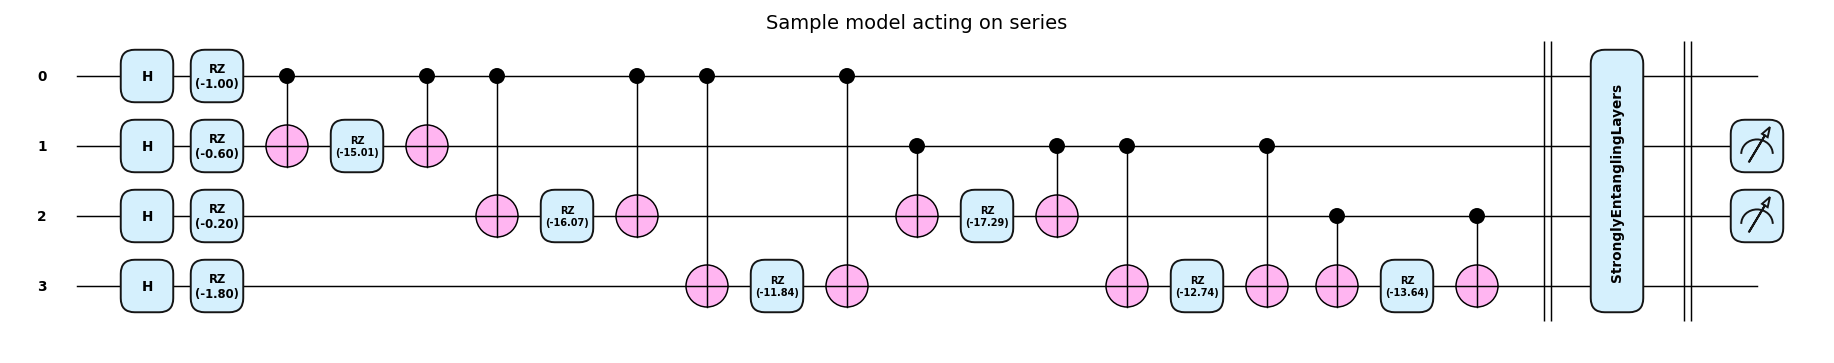

In [2]:
t_n_qubits = 4
t_n_layers = 2
t_inputs = [0.5, 0.3, 0.1, 0.9]
t_shape = gqnn_shape(t_n_layers, t_n_qubits)

t_inputs = torch.tensor(t_inputs, dtype=torch.float64)

dev = qml.device(sim, wires=t_n_qubits)
circuit = gqnn(
    t_n_layers,
    t_n_qubits,
    dev,
    interface=interface,
    diff_method=diff_method,
    fm_style="zzfm",
    meas=[1, 2],
)

title = f"Sample model acting on series"
draw_circuit(circuit, scale=0.7, title=title, level="user")(
    t_inputs,
)  # also try level='device'

## Datasets

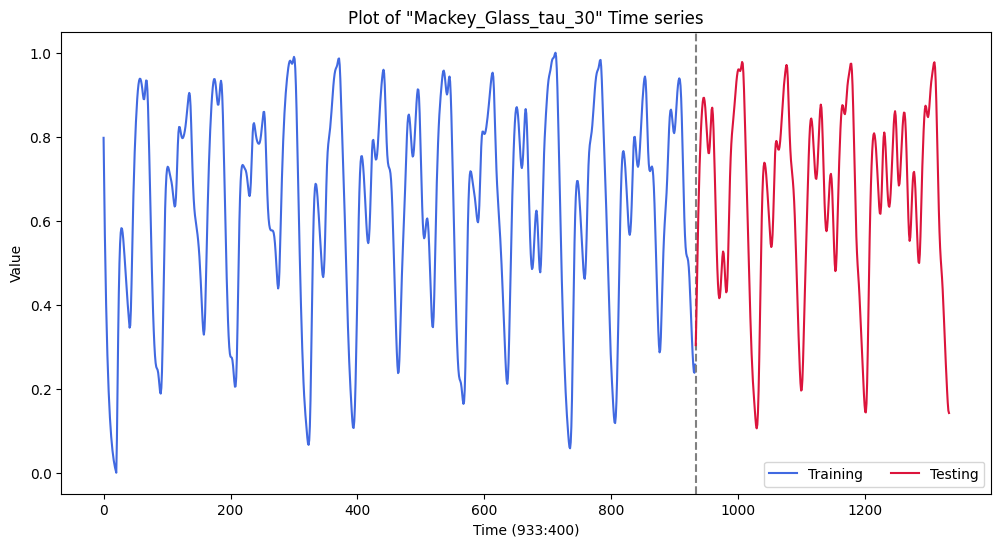

In [3]:
### Generate and plot the Mackey-Glass time series
time_series_mg30 = mackey_glass(tau=30)
chart_name_mg30 = "Mackey_Glass_tau_30"

# PLot this time series
y_temp_train, y_temp_test, _ = split_and_scale_series(time_series_mg30, TRAIN_FRACTION)
train_size, test_size = len(y_temp_train), len(y_temp_test)
x_temp_train = list(range(train_size))
x_temp_test = list(range(train_size, train_size + test_size))
multi_plot_flat_ts(
    [x_temp_train, x_temp_test],
    [y_temp_train, y_temp_test],
    dpi=100,
    rcParams=(12, 6),
    vert_lines=["", "dashed"],
    vert_line_color="gray",
    colors=["royalblue", "crimson"],
    lines=["solid", "solid"],
    xlabel=f"Time ({train_size}:{test_size})",
    ylabel="Value",
    labels=["Training", "Testing"],
    title=f'Plot of "{chart_name_mg30}" Time series',
    save_plot=FIGURES_DIR / f"xfig_series_{chart_name_mg30}.png",
)

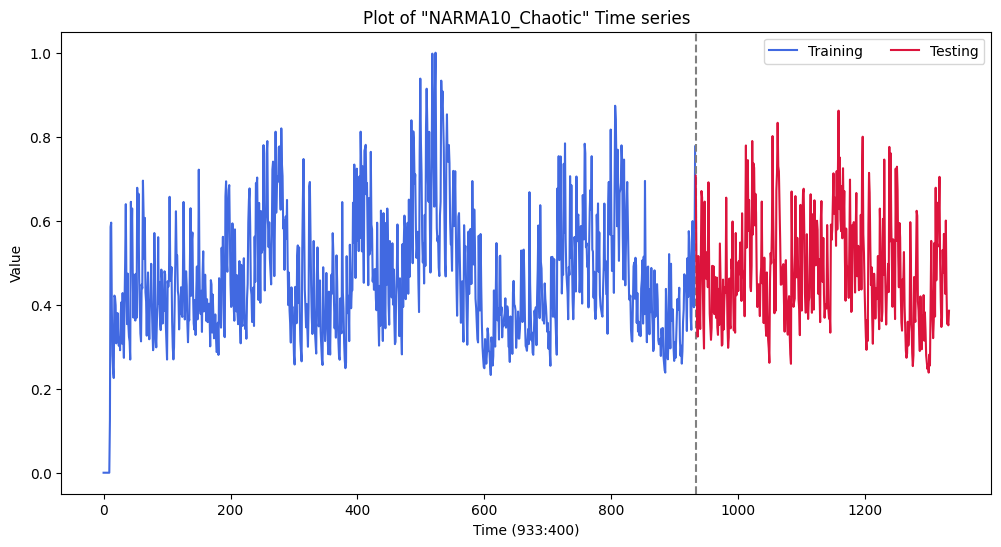

In [4]:
### Generate and plot NARMA10 time series
time_series_narma10 = generate_narma_data(order=10)
chart_name_narma10 = "NARMA10_Chaotic"

# PLot this time series
y_temp_train, y_temp_test, _ = split_and_scale_series(
    time_series_narma10, TRAIN_FRACTION
)
train_size, test_size = len(y_temp_train), len(y_temp_test)
x_temp_train = list(range(train_size))
x_temp_test = list(range(train_size, train_size + test_size))
multi_plot_flat_ts(
    [x_temp_train, x_temp_test],
    [y_temp_train, y_temp_test],
    dpi=100,
    rcParams=(12, 6),
    vert_lines=["", "dashed"],
    vert_line_color="gray",
    colors=["royalblue", "crimson"],
    lines=["solid", "solid"],
    xlabel=f"Time ({train_size}:{test_size})",
    ylabel="Value",
    labels=["Training", "Testing"],
    title=f'Plot of "{chart_name_narma10}" Time series',
    save_plot=FIGURES_DIR / f"xfig_series_{chart_name_narma10}.png",
)

In [5]:
time_series = time_series_mg30
chart_name = chart_name_mg30

In [6]:
### Prepare the data, scale to [0..1]
def create_io_pairs(data, window_size):
    """
    Create input-output pairs for training/testing.
    """
    inputs = []
    outputs = []
    target_indicies = []

    for i in range(len(data) - window_size):
        inputs.append(data[i: i + window_size])
        outputs.append(data[i + window_size])

    return np.array(inputs), np.array(outputs)


### Data settings
window_size = 4  # 2 4 6 8
train_size = int(len(time_series) * TRAIN_FRACTION)
test_size = len(time_series) - train_size

### Create data
train_inputs, train_outputs = create_io_pairs(time_series[:train_size], window_size)
test_inputs, test_outputs = create_io_pairs(
    time_series[train_size: train_size + test_size], window_size
)

In [7]:
dataset_path = Path(project_root) / "projects" / "trainability_effective_dim" / "datasets"
dataset_path.mkdir(parents=True, exist_ok=True)

train_dataset = TensorDataset(
    torch.tensor(train_inputs, dtype=torch.float64),
    torch.tensor(train_outputs, dtype=torch.float64),
)
test_dataset = TensorDataset(
    torch.tensor(test_inputs, dtype=torch.float64),
    torch.tensor(test_outputs, dtype=torch.float64),
)

torch.save(train_dataset, dataset_path / f"train_dataset_{chart_name}.pt")
torch.save(test_dataset, dataset_path / f"test_dataset_{chart_name}.pt")

## Training and investigation

### Basic pipeline

In [21]:
dataset_path = Path(project_root) / "projects" / "trainability_effective_dim" / "datasets"

chart_name = "Mackey_Glass_tau_30"
training_path = dataset_path / f"train_dataset_{chart_name}.pt"
validating_path = dataset_path / f"train_dataset_{chart_name}.pt"

trainer = BasicTrainer(
    training_path=training_path,
    validating_path=validating_path,
    testing_path=None,
    criterion=nn.MSELoss(),
)

In [22]:
model_config = {
    "n_layers": 5,
    "n_qubits": 4,
    "sim": "lightning.qubit",
    "interface": "torch",  # Changed from autograd
    "dif_method": "adjoint",
    "fm_style": "iqp",
    "meas": [0],
}
training_config = {
    "number_of_training_workers": 4,
    "number_of_validating_workers": 2,
    "number_of_testing_workers": 2,
    "batch_size": 1,
    "device": "cpu",
    "epochs": 20,
    "optimizer": {
        "name": "Adam",
        "lr": 0.016329429672802688,
        "momentum": 0.0,
        "weight_decay": 1.5061369169597726e-05,
    },
    "regularization": {
        "type": None,
        "lambda": None,
    },
}

config = {
    "model_config": model_config,
    "training_config": training_config,
}

net, training_metrics = trainer.train_model(config, gqnn)

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

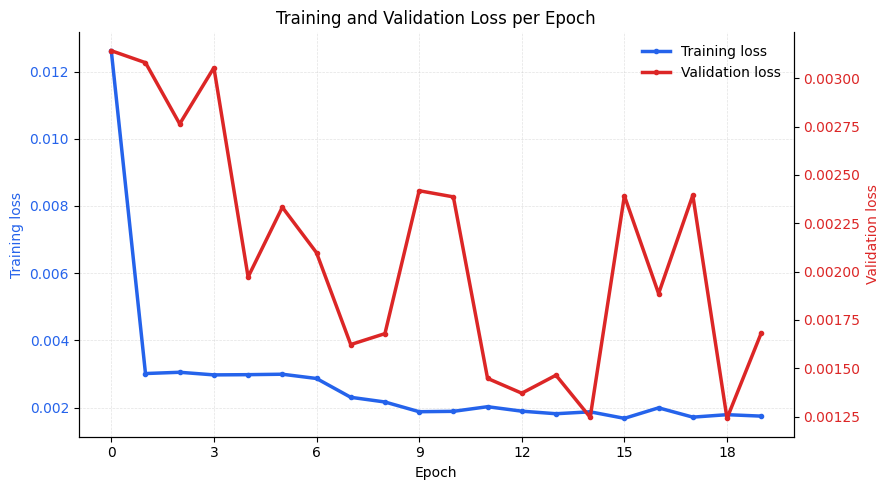

In [23]:
training_loss = training_metrics["training_loss"]
validating_loss = training_metrics["validating_loss"]
epochs = range(len(training_loss))

fig, ax_train = plt.subplots(figsize=(9, 5))
ax_valid = ax_train.twinx()

train_line = ax_train.plot(
    epochs,
    training_loss,
    color="#2563EB",
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Training loss",
)

valid_line = ax_valid.plot(
    epochs,
    validating_loss,
    color="#DC2626",
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Validation loss",
)

ax_train.set_title("Training and Validation Loss per Epoch")
ax_train.set_xlabel("Epoch")

ax_train.set_ylabel("Training loss", color="#2563EB")
ax_valid.set_ylabel("Validation loss", color="#DC2626")

ax_train.tick_params(axis="y", labelcolor="#2563EB")
ax_valid.tick_params(axis="y", labelcolor="#DC2626")

ax_train.grid(True, linestyle="--", alpha=0.35)
ax_train.spines["top"].set_visible(False)
ax_valid.spines["top"].set_visible(False)

lines = train_line + valid_line
ax_train.legend(lines, [line.get_label() for line in lines], frameon=False)
ax_train.xaxis.set_major_locator(MaxNLocator(integer=True))

fig.tight_layout()
plt.show()

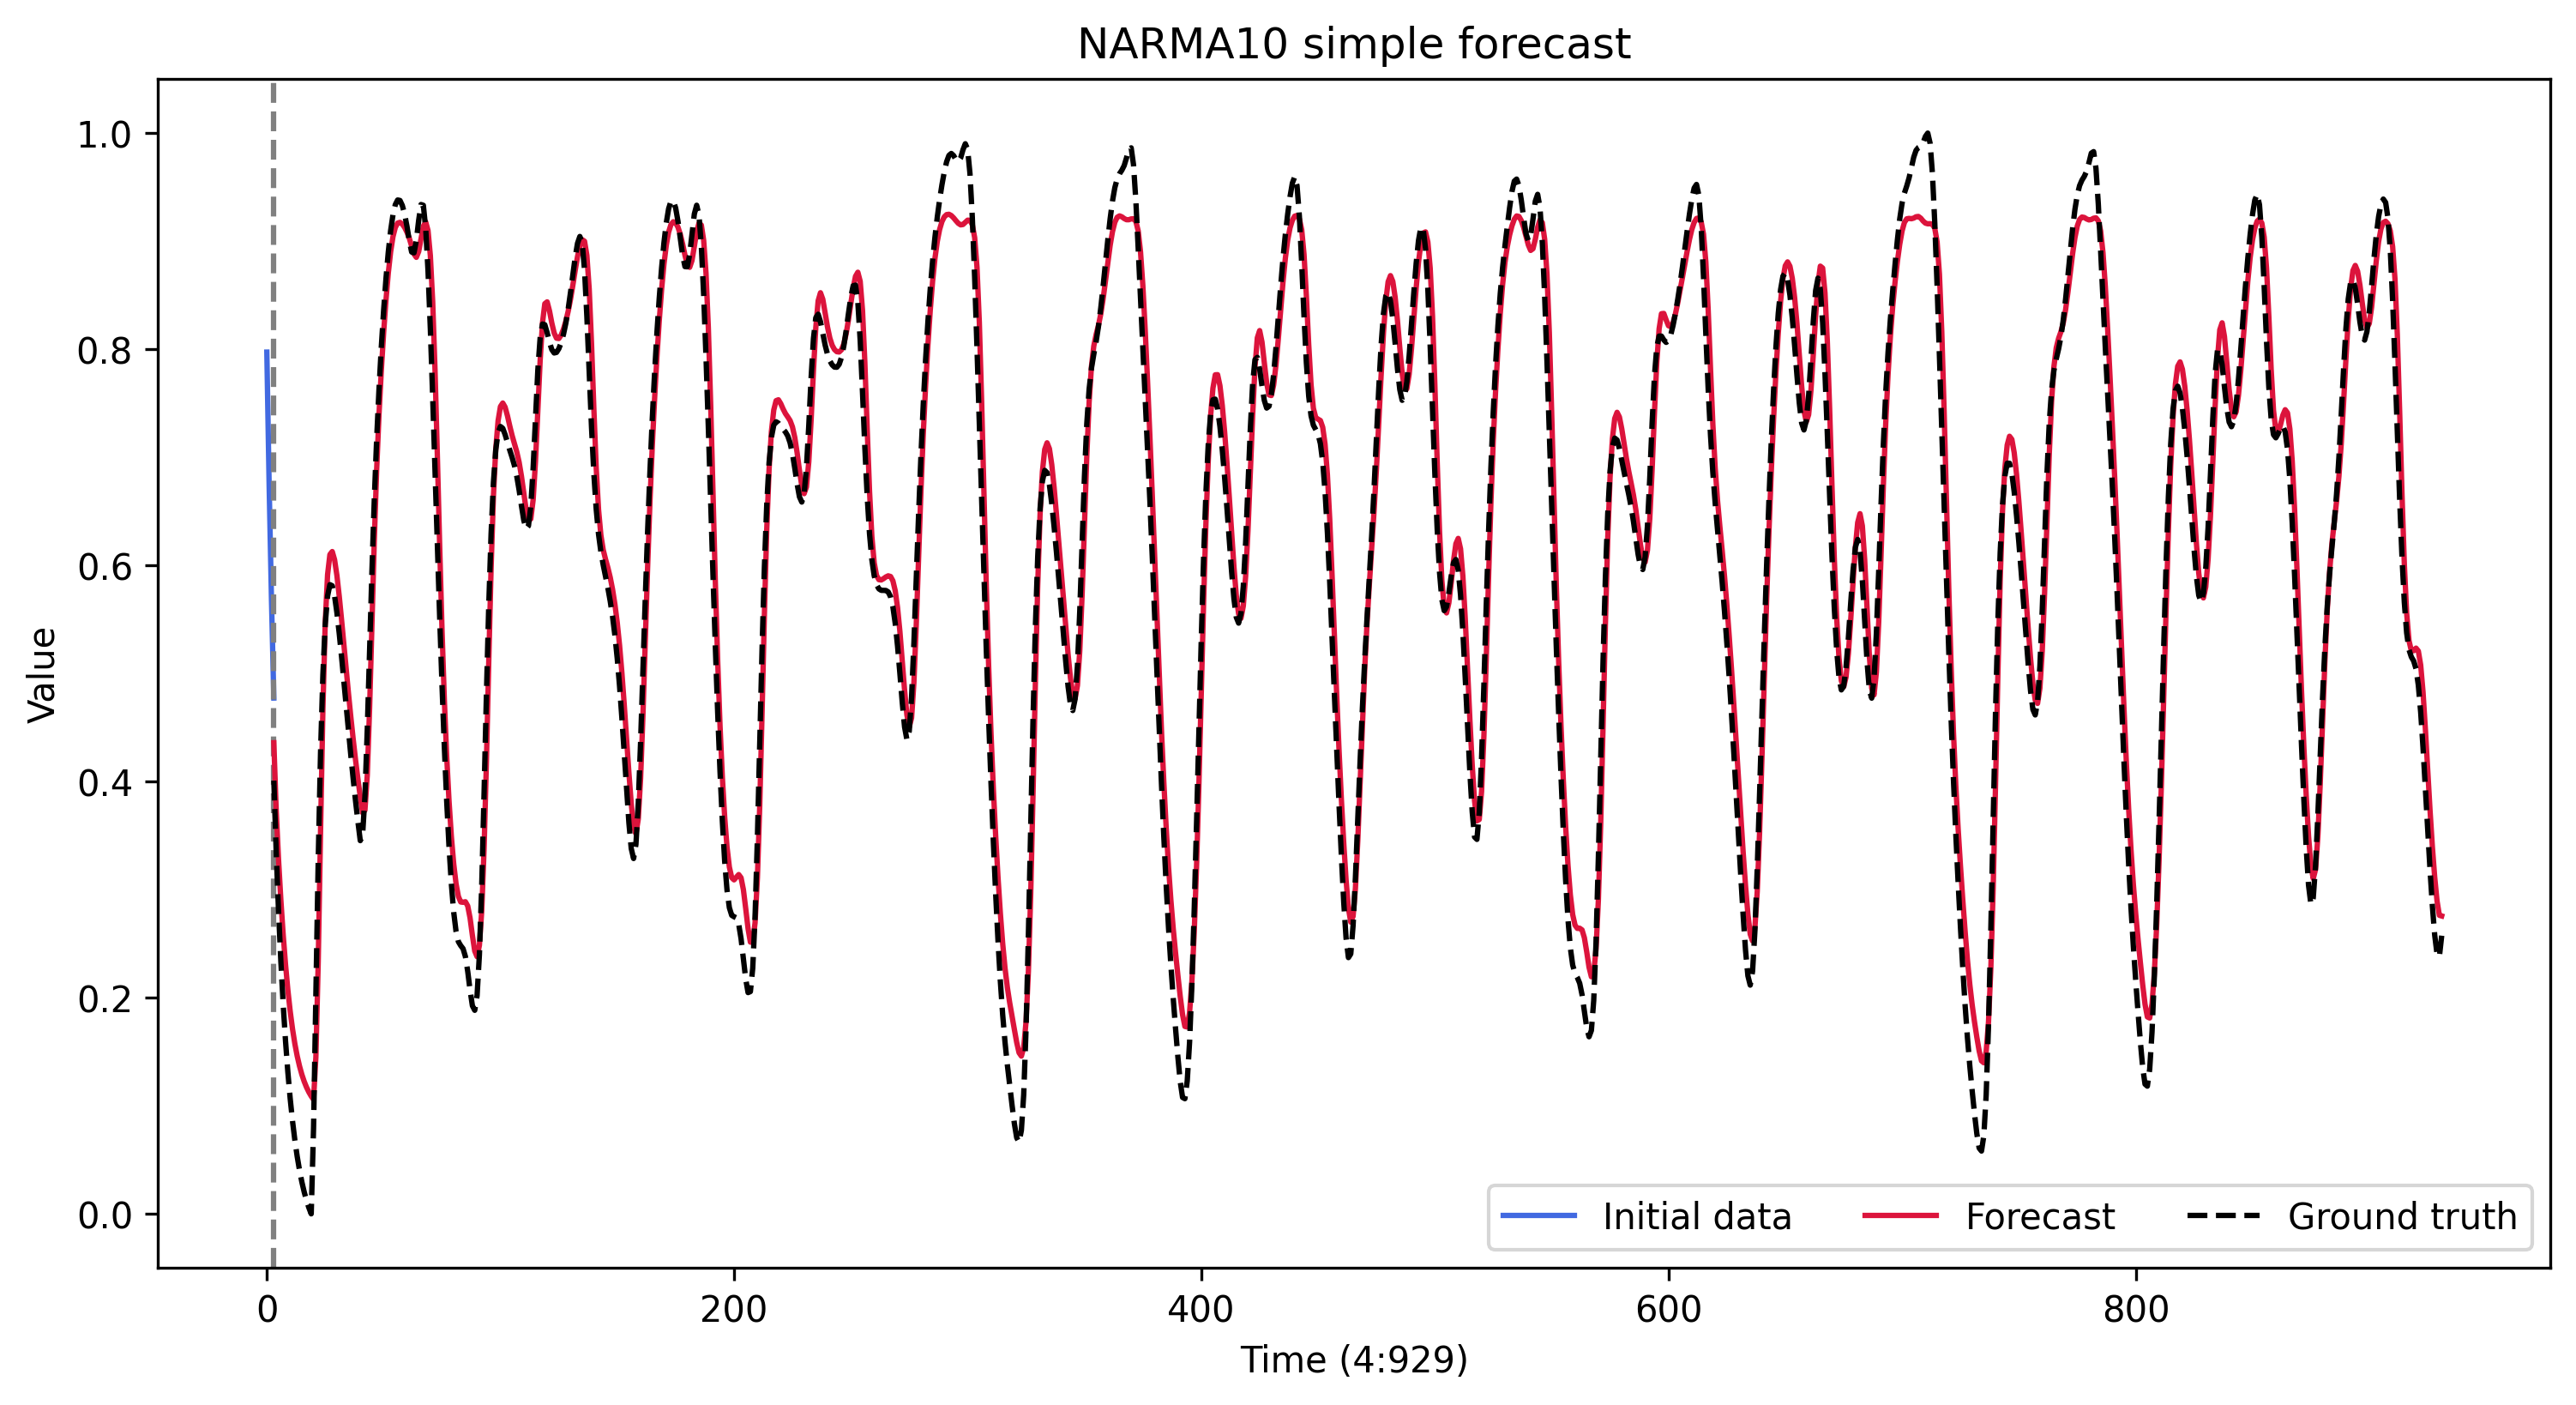

In [24]:
initial_data, forecasts, ground_truth = trainer.test_simple_forecast(net, None)

forecasts = np.concatenate([initial_data[-1]], forecasts)
ground_truth = np.concatenate([initial_data[-1]], ground_truth)

initial_data = initial_data.reshape(-1)
forecasts = forecasts.reshape(-1)
ground_truth = ground_truth.reshape(-1)

initial_size = len(initial_data)
forecast_size = len(forecasts)

x_initial = list(range(initial_size))
x_forecast = list(range(initial_size - 1, initial_size - 1 + forecast_size))
x_ground_truth = list(range(initial_size - 1, initial_size - 1 + len(ground_truth)))

multi_plot_flat_ts(
    [x_initial, x_forecast, x_forecast],
    [initial_data, forecasts, ground_truth],
    dpi=300,
    rcParams=(12, 6),
    vert_lines=["", "dashed", ""],
    vert_line_color="gray",
    colors=["royalblue", "crimson", "black"],
    lines=["solid", "solid", "dashed"],
    xlabel=f"Time ({initial_size}:{forecast_size})",
    ylabel="Value",
    labels=["Initial data", "Forecast", "Ground truth"],
    title="NARMA10 simple forecast",
    save_plot=FIGURES_DIR / "xfig_narma10_simple_forecast.png",
)

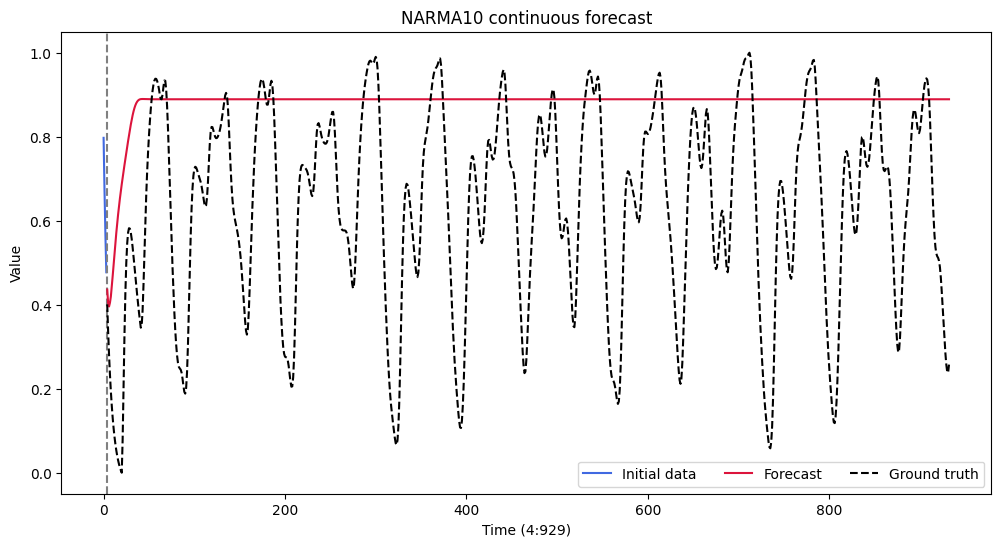

In [25]:
initial_data, forecasts, ground_truth = trainer.test_continuous_forecast(net, None)

forecasts = np.concatenate([initial_data[-1]], forecasts)
ground_truth = np.concatenate([initial_data[-1]], ground_truth)

initial_data = initial_data.reshape(-1)
forecasts = forecasts.reshape(-1)
ground_truth = ground_truth.reshape(-1)

initial_size = len(initial_data)
forecast_size = len(forecasts)

x_initial = list(range(initial_size))
x_forecast = list(range(initial_size, initial_size + forecast_size))

multi_plot_flat_ts(
    [x_initial, x_forecast, x_forecast],
    [initial_data, forecasts, ground_truth],
    dpi=100,
    rcParams=(12, 6),
    vert_lines=["", "dashed", ""],
    vert_line_color="gray",
    colors=["royalblue", "crimson", "black"],
    lines=["solid", "solid", "dashed"],
    xlabel=f"Time ({initial_size}:{forecast_size})",
    ylabel="Value",
    labels=["Initial data", "Forecast", "Ground truth"],
    title="NARMA10 continuous forecast",
    save_plot=FIGURES_DIR / "xfig_narma10_simple_forecast.png",
)

### Hyperparameter search

In [ ]:
dataset_path = Path("datasets")
chart_name = "Mackey_Glass_tau_30"
training_path = dataset_path / f"train_dataset_{chart_name}.pt"
validating_path = dataset_path / f"train_dataset_{chart_name}.pt"

trainer = HyperparameterTrainer(
    training_path=training_path,
    validating_path=validating_path,
    testing_path=None,
    criterion=nn.MSELoss(),
)

In [ ]:
def objective(trial):
    model_config = {
        "n_layers": trial.suggest_int("layers", 1, 5),
        "n_qubits": 4,
        "sim": "lightning.qubit",
        "interface": "torch",  # Changed from autograd
        "dif_method": "adjoint",
        "fm_style": trial.suggest_categorical("ansatz", ["zzfm", "iqp", "X"]),
        "meas": [0],
    }

    training_config = {
        "number_of_training_workers": 4,
        "number_of_validating_workers": 2,
        "number_of_testing_workers": 2,
        "batch_size": 1,
        "device": "cpu",
        "epochs": 20,
        "optimizer": {
            "name": "Adam",
            "lr": trial.suggest_float("lr", 1e-5, 1e-1, log=True),
            "momentum": 0.0,
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        },
        "regularization": {
            "type": trial.suggest_categorical("regularization", ["none", "l1", "l2"]),  # or None
            "lambda": trial.suggest_float("lambda", 1e-6, 1e-4, log=True),  # or None
        },
    }

    config = {
        "model_config": model_config,
        "training_config": training_config,
    }

    net, training_metrics = trainer.train_model(trial, config, gqnn)

    return min(training_metrics["validating_loss"])


pruner = optuna.pruners.HyperbandPruner(
    min_resource=5,
)

study = optuna.create_study(direction="minimize", pruner=pruner)
print("Starting Optuna Hyperparameter Search...")

study.optimize(objective, n_trials=10)

print("\n" + "=" * 50)
print("HYPERPARAMETER SEARCH COMPLETED")
print(f"Best trial final validation accuracy: {study.best_value:.4f}")
print(f"Best trial config: {study.best_params}")
print("=" * 50)

with open("results/hyperparameter_search_results.pkl", 'wb') as f:
    pickle.dump(study, f)